In [1]:
# -*- coding: utf-8 -*-
"""
@author: Jesper
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
from matplotlib.animation import FuncAnimation
import time
from scipy.optimize import curve_fit

# ------------------ Plot settings ------------------
plt.rcParams['figure.figsize'] = (10, 6)        # Default figure size
plt.rcParams['figure.dpi'] = 100                # Resolution
plt.rcParams['font.size'] = 16                  # Font size
plt.rcParams['axes.titlesize'] = 14             # Title font size
plt.rcParams['axes.labelsize'] = 22             # Axis label font size
plt.rcParams['xtick.labelsize'] = 19            # X-tick label size
plt.rcParams['ytick.labelsize'] = 19            # Y-tick label size
plt.rcParams['legend.fontsize'] = 22            # Legend font size
plt.rcParams['lines.linewidth'] = 2             # Line width
plt.rcParams['axes.grid'] = True                # Show grid by default
plt.rcParams['grid.alpha'] = 0.3                # Grid transparency

# Set global tick mark (line) sizes
plt.rcParams['xtick.major.size'] = 8      # Major tick length (horizontal)
plt.rcParams['ytick.major.size'] = 8      # Major tick length (vertical)
plt.rcParams['xtick.minor.size'] = 4      # Minor tick length (horizontal)
plt.rcParams['ytick.minor.size'] = 4      # Minor tick length (vertical)

# Set tick width
plt.rcParams['xtick.major.width'] = 1.5   # Major tick width (horizontal)
plt.rcParams['ytick.major.width'] = 1.5   # Major tick width (vertical)
plt.rcParams['xtick.minor.width'] = 1.5   # Major tick width (horizontal)
plt.rcParams['ytick.minor.width'] = 1.5   # Major tick width (vertical)
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Palatino", "Book Antiqua", "DejaVu Serif"],
})

In [2]:
def correct_iq(I, Q, return_params=False):

    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)
 
    dc_I = np.mean(I)
    dc_Q = np.mean(Q)
    I1 = I - dc_I
    Q1 = Q - dc_Q
 
    gain_I = np.sqrt(np.mean(I1 ** 2))
    gain_Q = np.sqrt(np.mean(Q1 ** 2))
 
    I2 = I1 / gain_I
    Q2 = Q1 / gain_Q
    
    cross = np.mean(I2 * Q2)
    sin_delta = np.clip(cross, -1.0, 1.0)
    delta = np.arcsin(sin_delta)
 
    cos_delta = np.cos(delta)

    I_corr = I2
    Q_corr = (Q2 - I2 * np.sin(delta)) / cos_delta
 
    if return_params:
        params = {
            'dc_I':      dc_I,
            'dc_Q':      dc_Q,
            'gain_I':    gain_I,
            'gain_Q':    gain_Q,
            'delta':     delta,
            'delta_deg': np.degrees(delta),
        }
        return I_corr, Q_corr, params
 
    return I_corr, Q_corr

In [3]:
def read_metadata(filename):
    meta = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if ":" not in line:
                continue

            parts = line.split(":")

            # Most entries are Key:Value:
            if len(parts) >= 2:
                key = parts[0]
                value = parts[1]

                meta[key] = value

    return meta



In [10]:
def read_and_process_csv(filename = None, foldername = None, path = None):
    if path == None:
        file_path = fr'{foldername}/{filename}.csv'
    else:
        file_path = path
    print(file_path)

    meta = read_metadata(file_path[:-8] + ".csv") #since data file is filename + .wfm.csv and metadata file is + .csv

    dt = float(meta["SignalResolution"])

    print("now proccessing file at path: ", file_path)
    df = pd.read_csv(file_path, header=None, delimiter=';')
    if len(df.columns) == 5:
        df.columns = ['time', 'ch_1', 'ch_2', 'ch_3', 'ch_4']
        time = df['time']
        ch_one = df['ch_1']    
        ch_two = df['ch_2']    
        ch_three = df['ch_3']    
        ch_four = df['ch_4']
        size = len(ch_one)
        print("Size: ", size)
        print("Frequency resolution: ", 1/(time[1] - time[0]))
        
        return time[0:size], ch_one[0:size], ch_two[0:size], ch_three[0:size], ch_four[0:size], size

    elif len(df.columns) == 4:
            df.columns = ['ch_1', 'ch_2', 'ch_3', 'ch_4']

            
            
            ch_one = df['ch_1']    
            ch_two = df['ch_2']    
            ch_three = df['ch_3']    
            ch_four = df['ch_4']
            size = len(ch_one)

            time = np.arange(size) * dt

            df['time'] = time #Adding time column to the dataframe
      

            print("Size: ", size)
            print("Frequency resolution: ", 1/(time[1] - time[0]))
            
            return time[0:size], ch_one[0:size], ch_two[0:size], ch_three[0:size], ch_four[0:size], size
    
        
    
def pnpsd(filenames, foldername, averaging_number):
    """
    Calculates sdd for phase noise power spectral density using cross spectral density csd. Returns the PN-PSD. 
    """   
    timeX, ch_one, ch_two, ch_three, ch_four, size = read_and_process_csv(filenames, foldername)

    NN=size//averaging_number               # // to make sure that it gets an integer and not a float
    window = scipy.signal.get_window('hann', NN)

    psdxx0=0
    fxx=0

    psdyy0=0
    fyy=0

    psdxy0=0
    fxy=0

    ch_one, ch_two = correct_iq(ch_one, ch_two)
    ch_three, ch_four = correct_iq(ch_three, ch_four)

    phaseX,sampling_rateX=pp(ch_one, ch_two, timeX)
    phaseY,sampling_rateY=pp(ch_three, ch_four, timeX)

    ffxx = 0
    Pxx_den = 0

    ffxy = 0
    Pxy_den = 0

    ffyy = 0
    Pyy_den = 0

    ffxx, Pxx_den = scipy.signal.csd(phaseX, phaseX, fs=sampling_rateX,window=window,nperseg=NN)
    psdxx0=psdxx0 + Pxx_den
    fxx=ffxx+fxx

    ffxy, Pxy_den = scipy.signal.csd(phaseX, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdxy0=psdxy0 + Pxy_den
    fxy=ffxy+fxy

    ffyy, Pyy_den = scipy.signal.csd(phaseY, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdyy0=psdyy0 + Pyy_den
    fyy=ffyy+fyy

    psdxx0=np.abs(psdxx0)

    psdyy0=np.abs(psdyy0)

    psdxy0=np.abs(psdxy0)

    # Shitty namings, but it returns frequency and PN-PSD for the x-polarization, y-polarization and the cross correlated

    return fxx, psdxx0, fyy, psdyy0, fxy, psdxy0

def pnpsd_noQAM(filenames, foldername, averaging_number):
    """
    Calculates sdd for phase noise power spectral density using cross spectral density csd. Returns the PN-PSD. 
    """   
    timeX, ch_one, ch_two, ch_three, ch_four, size = read_and_process_csv(filenames, foldername)

    NN=size//averaging_number               # // to make sure that it gets an integer and not a float
    window = scipy.signal.get_window('hann', NN)

    psdxx0=0
    fxx=0

    psdyy0=0
    fyy=0

    psdxy0=0
    fxy=0

    phaseX,sampling_rateX=pp(ch_one, ch_two, timeX)
    phaseY,sampling_rateY=pp(ch_three, ch_four, timeX)

    ffxx = 0
    Pxx_den = 0

    ffxy = 0
    Pxy_den = 0

    ffyy = 0
    Pyy_den = 0

    ffxx, Pxx_den = scipy.signal.csd(phaseX, phaseX, fs=sampling_rateX,window=window,nperseg=NN)
    psdxx0=psdxx0 + Pxx_den
    fxx=ffxx+fxx

    ffxy, Pxy_den = scipy.signal.csd(phaseX, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdxy0=psdxy0 + Pxy_den
    fxy=ffxy+fxy

    ffyy, Pyy_den = scipy.signal.csd(phaseY, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdyy0=psdyy0 + Pyy_den
    fyy=ffyy+fyy

    psdxx0=np.abs(psdxx0)

    psdyy0=np.abs(psdyy0)

    psdxy0=np.abs(psdxy0)

    return fxx, psdxx0, fyy, psdyy0, fxy, psdxy0

def pp(XI,XQ,time):
    """
    Returns the accumulated phase using the arctan2 function and the sampling rate by
    """
    phase= np.unwrap(np.arctan2(XQ, XI))
    dt=time[2]-time[1]
    sampling_rate=1/dt
    return phase, sampling_rate

def fnpsd(fxy, psdxy, FSR):
    # fsdd for frequency noise power spectral density. Returns the FN-PSD.

    fsdxy = []

    for i, _ in enumerate(fxy):
        fsdxy.append(fxy[i] ** 2 / (4 * np.sin(np.pi * fxy[i] * 1/FSR) ** 2) * psdxy[i])
            
    return np.array(fxy),np.array(fsdxy)

def find_fsr(freq, pn_psd, FSR_est, upper_lim, peak_skips=0, show_detection = False):

    # Function for finding the FSR from the dips, that is needed for the PN --> FN conversion. Returns the average distance 
    # between the dips as the FSR and the peaks that are detected.

    # Since 

    def model_plus(f, A, B, C):
        return A / (f**2) + B / (f**3) + C

    def fit_one_over_f_squared_plus(f, y):
        popt, pcov = curve_fit(model_plus, f, y, p0=(6e2, 1e9, 1))
        return popt, pcov

    f_min = (0.75)/(FSR_est / (3e8/1.46))
    mask = (freq < upper_lim) & (freq > f_min)
    f_sub = freq[mask]
    psd_sub = -pn_psd[mask]

    delta_f = f_min
    df = freq[1] - freq[0]

    delta_i = int(round(delta_f / df))

    peaks, props = scipy.signal.find_peaks(psd_sub, distance = delta_i*0.9)

    peak_temp = f_sub[peaks][peak_skips:]
    psd_temp = -psd_sub[peaks][peak_skips:]

    f_dist_peaks = np.median(np.diff(peak_temp))

    popt, pcov = fit_one_over_f_squared_plus(f_sub[peaks][peak_skips:], -psd_sub[peaks][peak_skips:])

    if show_detection:
        fig, ax = plt.subplots(figsize =(20, 7.5))
        ax.loglog(freq, pn_psd, label = "Input signal")
        #ax.loglog(freq, model(freq, popt[0], popt[1]), label = "1/f^2 fit")

        ax.scatter(peak_temp, psd_temp, label = "Detected fringes", color = "red")

        ax.loglog(freq, model_plus(freq, popt[0], popt[1], popt[2]), linestyle = "dashed", color = "black")

        ax.vlines(f_min, min(pn_psd), max(pn_psd), label = "Limits for detection", linestyles="dashed", color = "black")

        ax.vlines(upper_lim, min(pn_psd), max(pn_psd), linestyles="dashed", color = "black")

        print("Params from fit:")
        print("A = ", popt[0])
        print("B = ", popt[1])
        print("C = ", popt[2])

        ax.set_title("Detected dips in the PN-FSD for FSR determination", fontsize = 25)
        ax.set_ylabel(rf"PN-FSD [rad$^2$/Hz]")
        ax.set_xlabel("Fourier frequencies [Hz]")
        ax.set_xlim(1e2, 1e7)
        ax.legend()
        
    return f_dist_peaks, f_sub[peaks], -psd_sub[peaks]


## For quick examination of data, simply use the pnpsd function

## If the QAM is acting up, use pnpsd_noQAM instead

In [38]:
f_x, psd_x, f_y, psd_y, f_xy, psd_xy = pnpsd("PPCL_Whisper_14.11dBm_12.11+7.48dBm_20MSa_s_not_raw.Wfm", r"C:\Users\au617810\Downloads",2000)

C:\Users\au617810\Downloads/PPCL_Whisper_14.11dBm_12.11+7.48dBm_20MSa_s_not_raw.Wfm.csv
now proccessing file at path:  C:\Users\au617810\Downloads/PPCL_Whisper_14.11dBm_12.11+7.48dBm_20MSa_s_not_raw.Wfm.csv
Size:  20000000
Frequency resolution:  20000000.0


(1e-12, 10000.0)

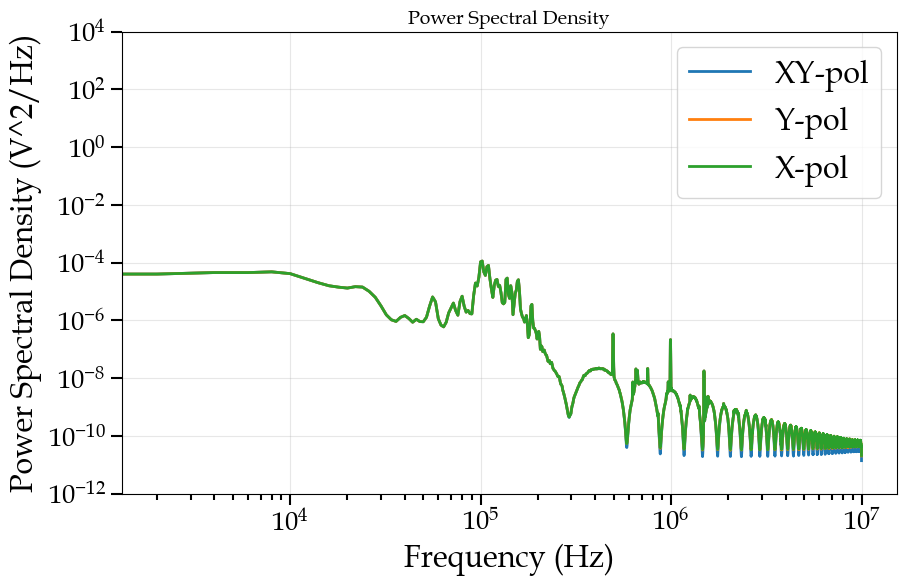

In [39]:
plt.figure(figsize=(10, 6))
plt.loglog(f_xy, psd_xy, label = "XY-pol")
plt.loglog(f_y, psd_y, label = "Y-pol")
plt.loglog(f_x, psd_x, label = "X-pol")
# plt.loglog(f_xy, psd_xy, label = "XY-pol",alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.title("Power Spectral Density")
plt.legend()
plt.grid(True)
plt.ylim(1e-12, 1e4)

(1000000.0, 8000000.0)

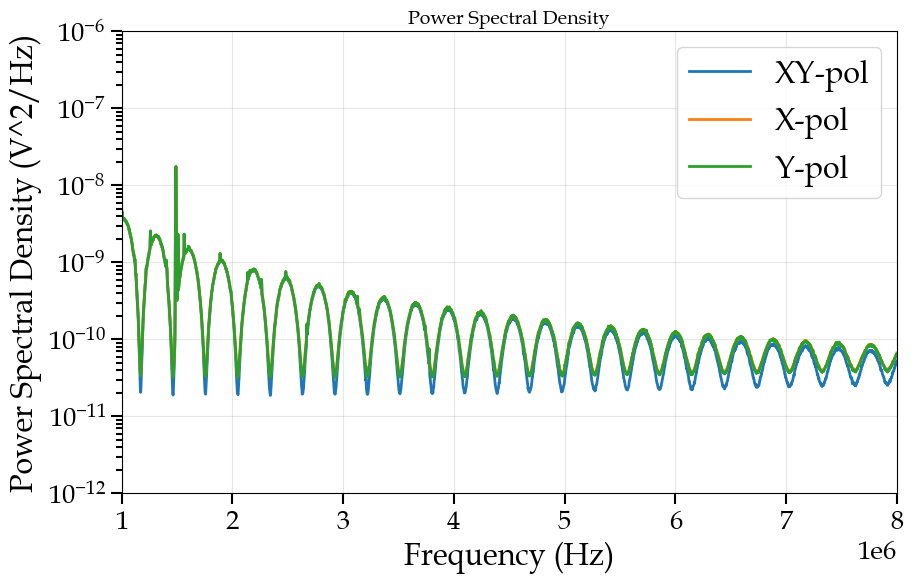

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(f_xy, psd_xy, label = "XY-pol")
plt.plot(f_x, psd_x, label = "X-pol")
plt.plot(f_y, psd_y, label = "Y-pol")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.title("Power Spectral Density")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.ylim(1e-12, 1e-6)
plt.xlim(1e6, 8e6)

In [ ]:
l